Inspired by [python-agent-framework-ghmodel-workflow-multi-agents.ipynb](https://github.com/microsoft/Agent-Framework-Samples/blob/main/00.ForBeginners/08-multi-agent/code_samples/python-agent-framework-ghmodel-workflow-multi-agents.ipynb) and [01.python-agent-framework-workflow-ghmodel-basic.ipynb](https://github.com/microsoft/Agent-Framework-Samples/blob/main/07.Workflow/code_samples/python/01.python-agent-framework-workflow-ghmodel-basic.ipynb)

# Common Libraries and Global Variables

In [1]:
# Common Libraries
import os, sys
from dotenv import load_dotenv # requires python-dotenv
from IPython.display import Markdown, display

config_path = "../../../config" # explicit path to the config folder
sys.path.append(config_path)
from auth import acquire_bearer_token, StaticBearerTokenCredential
if not load_dotenv(f"{config_path}/credentials_my.env"):
    print("Environment variables not loaded, cell execution stopped")
else:
    print("Environment variables have been loaded ;-)")

# Global libraries - recall to declare them as "global" in the functions where they are assigned
openai_endpoint = ""
openai_key = ""
model_id = ""

Environment variables have been loaded ;-)


# Authentication & Environment setup

# Initialization

In [2]:
def init():
    global openai_endpoint, openai_key, model_id
    
    openai_endpoint = os.getenv("GITHUB_ENDPOINT")
    openai_key = os.getenv("GITHUB_TOKEN")
    model_id = os.environ["GITHUB_MODEL_ID"]
    
init()

In [3]:
# 🔗 Create OpenAI Chat Client for GitHub Models
# This client connects to GitHub Models API (OpenAI-compatible endpoint)
# Environment variables required:
# - GITHUB_ENDPOINT: API endpoint URL (usually https://models.inference.ai.azure.com)
# - GITHUB_TOKEN: Your GitHub personal access token
# - GITHUB_MODEL_ID: Model to use (e.g., gpt-4o-mini, gpt-4o)


# 🤖 Import Microsoft Agent Framework Components
# ChatAgent: The main agent class for conversational AI
# OpenAIChatClient: Client for connecting to OpenAI-compatible APIs (including GitHub Models)

from agent_framework import Agent
from agent_framework.openai import OpenAIChatClient

openai_chat_client = OpenAIChatClient(
    base_url=openai_endpoint,
    api_key=openai_key, 
    model_id=model_id
)

# 🤖 Create Agent Instances

In [4]:
# 🎩 Agent 1: Hotel Concierge - Quality Reviewer Role
# This agent specializes in evaluating travel recommendations for authenticity
# Acts as the second stage in our multi-agent workflow for quality assurance

REVIEWER_NAME = "Concierge"
REVIEWER_INSTRUCTIONS = """
    You are an experienced hotel concierge who has strong opinions about providing the most local and authentic experiences for travelers.
    
    Your role in this multi-agent workflow:
    - Review travel recommendations from the Front Desk agent
    - Assess whether suggestions provide authentic, non-touristy experiences
    - Approve recommendations that meet high standards for local authenticity
    - Provide constructive feedback for refinement without giving specific examples
    
    Always focus on the quality and authenticity of experiences rather than just popular tourist destinations.
    """

writer_agent = openai_chat_client.as_agent(
    name=REVIEWER_NAME,
    instructions=REVIEWER_INSTRUCTIONS,
)

In [5]:
# 🎩 Agent 1: Hotel Concierge - Quality Reviewer Role
# This agent specializes in evaluating travel recommendations for authenticity
# Acts as the second stage in our multi-agent workflow for quality assurance

FRONTDESK_NAME = "FrontDesk"
FRONTDESK_INSTRUCTIONS = """
    You are a Front Desk Travel Agent with ten years of experience and are known for brevity as you deal with many customers.
    The goal is to provide the best activities and locations for a traveler to visit.
    Only provide a single recommendation per response.
    You're laser focused on the goal at hand.
    Don't waste time with chit chat.
    Consider suggestions when refining an idea.
    """

agent_reviewer  = openai_chat_client.as_agent(
    name=FRONTDESK_NAME,
    instructions=FRONTDESK_INSTRUCTIONS,
)

# 🔄 Build the Multi-Agent Workflow

In [6]:
from agent_framework import AgentResponse, WorkflowBuilder
workflow = WorkflowBuilder(start_executor=writer_agent).add_edge(writer_agent, agent_reviewer).build()

# 🚀 Execute the Multi-Agent Workflow
Run the workflow with a travel request. The agents will collaborate:

First agent provides initial travel suggestion
Second agent reviews and potentially refines the recommendation
Results stream back showing each agent's contribution

In [7]:
events = await workflow.run("I would like to go to Paris.")
events

[WorkflowEvent(type='executor_invoked', executor_id='Concierge', data='I would like to go to Paris.'),
 WorkflowEvent(type='output', executor_id='Concierge', data=<agent_framework._types.AgentResponse object at 0x0000022829B7ED50>),
 WorkflowEvent(type='executor_completed', executor_id='Concierge', data=[AgentExecutorResponse(executor_id='Concierge', agent_response=<agent_framework._types.AgentResponse object at 0x0000022829B7ED50>, full_conversation=[<agent_framework._types.Message object at 0x000002282973B0E0>, <agent_framework._types.Message object at 0x0000022829B7DD10>]), <agent_framework._types.AgentResponse object at 0x0000022829B7E5D0>]),
 WorkflowEvent(type='superstep_started', iteration=1),
 WorkflowEvent(type='executor_invoked', executor_id='FrontDesk', data=AgentExecutorResponse(executor_id='Concierge', agent_response=<agent_framework._types.AgentResponse object at 0x000002282975CB00>, full_conversation=[<agent_framework._types.Message object at 0x0000022829ADB1D0>, <agent_

In [8]:
# The outputs of the workflow are whatever the agents produce. So the outputs are expected to be a list
# of `AgentResponse` from the agents in the workflow.
outputs = events.get_outputs()
outputs

In [9]:
from typing import cast

outputs = cast(list[AgentResponse], outputs) # not needed actually
outputs

In [10]:
for output in outputs:
    print(f"{output.messages[0].author_name}: {output.text}\n")

    # Summarize the final run state (e.g., COMPLETED)
print("Final state:", events.get_final_state())

Concierge: That sounds wonderful! Paris is filled with opportunities for authentic experiences. When creating an itinerary, consider exploring the lesser-known neighborhoods and indulging in local cuisine at bistros frequented by residents rather than tourists. Engaging with local artisans and attending cultural events can also provide a more genuine feel of the city. If you have recommendations in mind, feel free to share them, and I'll help refine them for authenticity!

FrontDesk: Visit Montmartre to explore its artistic heritage, charming streets, and stunning views of the city from the Sacré-Cœur Basilica.

Final state: WorkflowRunState.IDLE


Generating workflow visualization...
Mermaid string: 
flowchart TD
  Concierge["Concierge (Start)"];
  FrontDesk["FrontDesk"];
  Concierge --> FrontDesk;
DiGraph string: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "Concierge" [fillcolor=lightgreen, label="Concierge\n(Start)"];
  "FrontDesk" [label="FrontDesk"];
  "Concierge" -> "FrontDesk";
}
SVG file saved to: C:\Users\mauromi\AppData\Local\Temp\tmpkju0ounl.svg


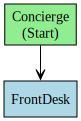

In [11]:
from agent_framework import WorkflowViz # requires uv add --active graphviz>=0.20.0
from IPython.display import SVG, display, HTML

print("Generating workflow visualization...")
viz = WorkflowViz(workflow)

# Print out the mermaid string.
print("Mermaid string: \n=======")
print(viz.to_mermaid())

print("=======")
# Print out the DiGraph string.
print("DiGraph string: \n=======")
print(viz.to_digraph())

print("=======")
svg_file = viz.export(format="svg")
print(f"SVG file saved to: {svg_file}")

display(SVG(filename=svg_file))

Attempting to display SVG file at: C:\Users\mauromi\AppData\Local\Temp\tmpkju0ounl.svg


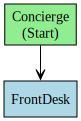

In [12]:
# Display the exported workflow SVG inline in the notebook

from IPython.display import SVG, display, HTML
import os

print(f"Attempting to display SVG file at: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # Preferred: direct SVG rendering
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ Direct SVG render failed: {e}. Falling back to raw HTML.")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ Fallback HTML render also failed: {inner}")
else:
    print("❌ SVG file not found. Ensure viz.export(format='svg') ran successfully.")